# Start

In [44]:
from ldst import waves_residual_split, reconstruct_y, normalize_torch

import torch
import torch.nn.functional as F
from torchvision import transforms
import tqdm
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

device = 'cuda'


# Definitions

# Do things

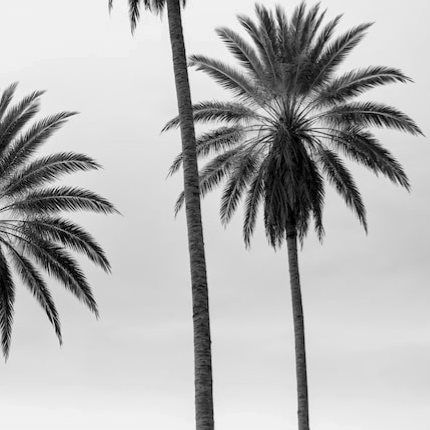

In [45]:
path_image = 'black-white-palm.png'
oi = Image.open(path_image)
oi


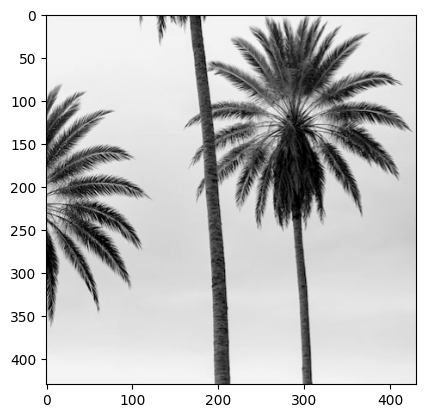

In [46]:
oi = transforms.ToTensor()(oi).unsqueeze(0).to(device)
plt.imshow(oi[0][0].cpu().numpy(), cmap='gray')

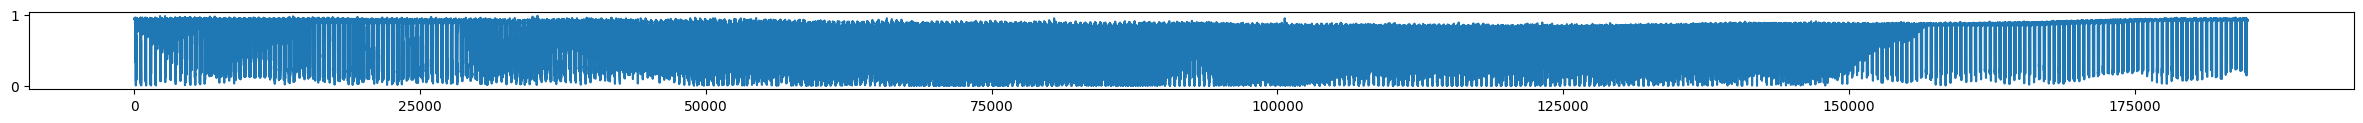

In [47]:
average_value = oi.mean()
wavelen = oi.shape[2]
rolling_window = 481
# rolling_window = oi.shape[2] // 2
# rolling_window = rolling_window if rolling_window % 2 else rolling_window + 1
oi_flat = oi.flatten()
n = oi_flat.numel()
x = torch.arange(n).to(device)


plt.figure(figsize=(30, 1))
plt.plot(x.cpu(), oi_flat.cpu())

In [48]:
num_waves = 1
learning_rate = 0.001

100%|██████████| 5/5 [00:00<00:00,  8.06it/s]


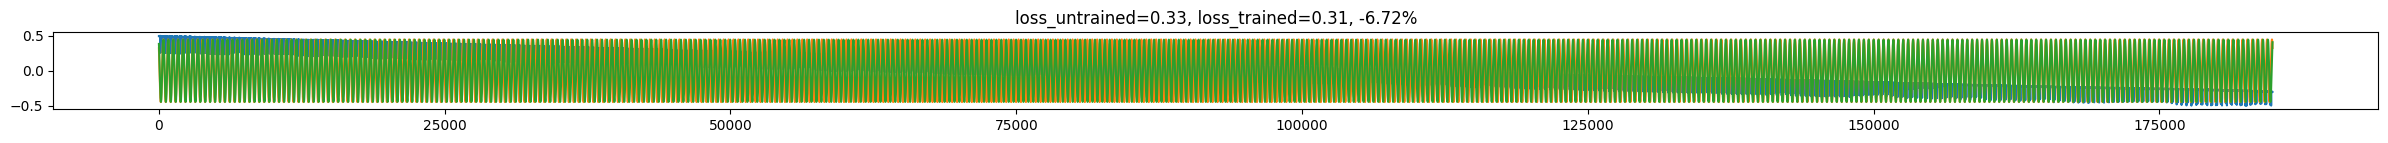

In [49]:
waves_params, residual = waves_residual_split(
    x_tensor=x,
    y_tensor=oi_flat,
    num_waves=num_waves,
    rolling_window=rolling_window,
    learning_rate=learning_rate,
    device=device,
    wavelen=wavelen,
    plot=True
)

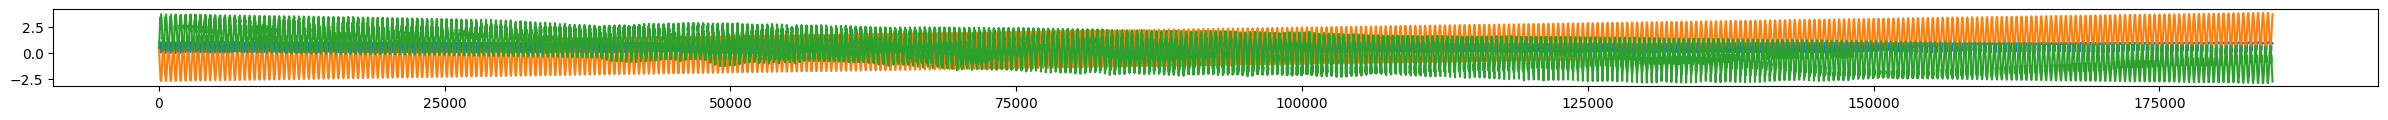

In [50]:
approximation = reconstruct_y(x, torch.zeros_like(oi_flat), waves_params)
residual = oi_flat - approximation
plt.figure(figsize=(30, 1))
plt.plot(x.cpu(), oi_flat.cpu())
plt.plot(x.cpu(), approximation.detach().cpu().numpy())
plt.plot(x.cpu(), residual.detach().cpu().numpy())
plt.show()

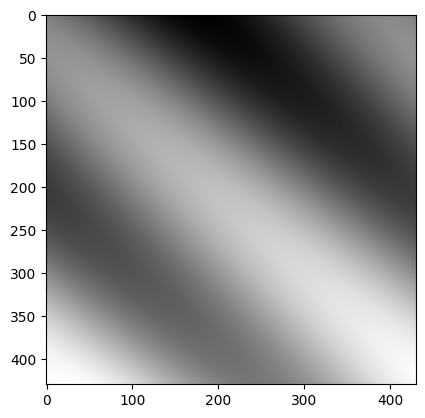

In [51]:
approx_norm = normalize_torch(approximation.reshape(oi.shape)[0][0])
plt.imshow(approx_norm.cpu(), cmap='gray')

In [52]:
wavelen = oi.shape[3]
t_oi_flat = oi.squeeze().T.flatten()
t_waves_params, t_residual = waves_residual_split(x_tensor=x, y_tensor=t_oi_flat, num_waves=num_waves, rolling_window=rolling_window, learning_rate=learning_rate, device=device, wavelen=wavelen, plot=False)

100%|██████████| 5/5 [00:00<00:00,  8.90it/s]


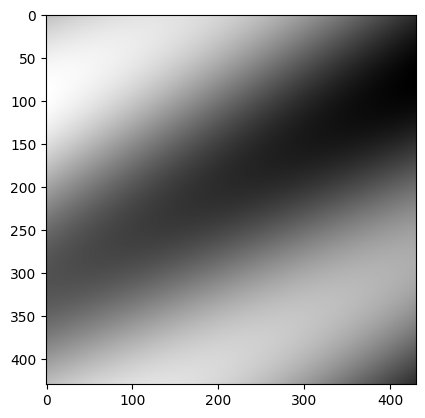

In [53]:
t_approximation = reconstruct_y(x, torch.zeros_like(t_oi_flat), t_waves_params)
t_residual = t_oi_flat - t_approximation
t_approx_norm = normalize_torch(t_approximation.reshape(oi.squeeze().shape)).T
plt.imshow(t_approx_norm.cpu(), cmap='gray')

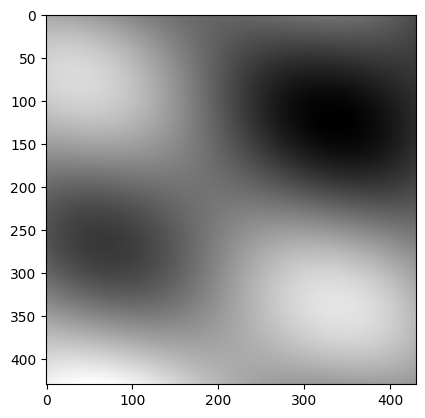

In [54]:
approx_combo = (approx_norm + t_approx_norm) / 2
plt.imshow(approx_combo.cpu(), cmap='gray')

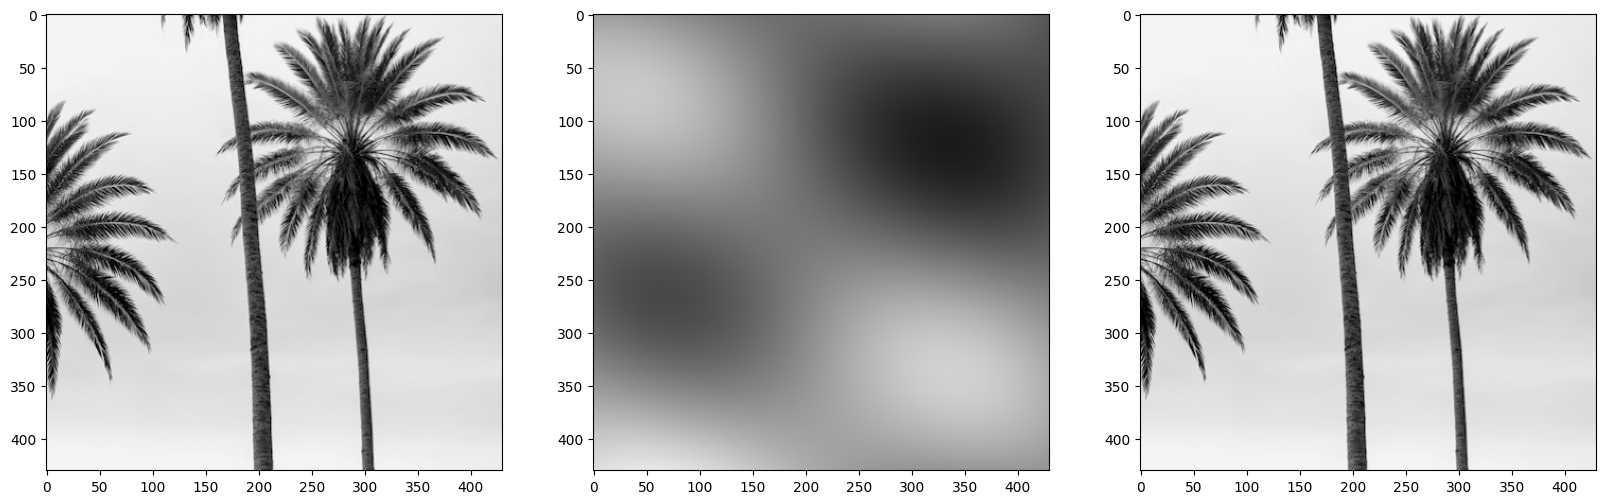

In [63]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6))
# ax[0].imshow((residual.reshape(oi.squeeze().shape).cpu() + t_residual.reshape(oi.squeeze().shape).T.cpu()) / 2, cmap='gray')
ax[0].imshow(oi.squeeze().cpu(), cmap='gray')
ax[1].imshow(approx_combo.cpu(), cmap='gray', vmin=0, vmax=1)
# ax[2].imshow(residual.reshape(oi.squeeze().shape).cpu() + t_residual.reshape(oi.squeeze().shape).T.cpu() + 0.25, cmap='gray', vmin=0, vmax=1)
ax[2].imshow(residual.reshape(oi.squeeze().shape).cpu() + approximation.reshape(oi.squeeze().shape).cpu(), cmap='gray')


In [56]:
(oi.squeeze() - approx_combo).abs().mean()

tensor(0.2833, device='cuda:0')

In [57]:
(oi.squeeze() - approx_norm).abs().mean()

tensor(0.2960, device='cuda:0')

In [58]:
(oi.squeeze() - t_approx_norm).abs().mean()

tensor(0.2951, device='cuda:0')

In [59]:
(oi.squeeze() - oi.squeeze().mean()).abs().mean()

tensor(0.2238, device='cuda:0')

# End